### EDA On DataSet

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Comicbooks.csv')
df

,product_price,product_rating,mrp,company,country,discount_pct,review_count,availability_status,language,writer,format,comic title
0,899,2.3,1758.0,Marvel,United States,48.0,3,low_stock,English,Hickman Jonathan,paperback,X-Men: Hellfire Gala
1,1178,0.0,1316.0,Marvel,United States,10.0,0,low_stock,English,Dbg,paperback,World of Reading Avengers Boxed Set
2,617,0.0,822.0,Marvel,United States,24.0,0,low_stock,English,Berrios Frank,hardcover,Trapped by the Green Goblin! (Marvel: Spider-Man)
3,522,3.9,699.0,Marvel,United States,25.0,8,low_stock,English,Dk,hardcover,Marvel Avengers The Ultimate Character Guide N...
4,899,5.0,1949.0,Marvel,United States,53.0,3,low_stock,English,Aaron Jason,paperback,Avengers By Jason Aaron Vol. 9
...,...,...,...,...,...,...,...,...,...,...,...,...
884,591,3.3,969.0,Japanese,Japan,39.0,3,promotion,English,Kishimoto Masashi,paperback,"Boruto: Naruto Next Generations, Vol. 15"
885,591,4.4,799.0,Japanese,Japan,26.0,13,in_stock,English,Kishimoto Masashi,paperback,"Naruto, Vol. 55"
886,591,4.8,799.0,Japanese,Japan,26.0,4,in_stock,English,Kishimoto Masashi,paperback,"Naruto, Vol. 13"
887,866,4.4,1655.0,Japanese,Japan,47.0,12,promotion,English,Aidairo Aidairo,paperback,"Toilet-bound Hanako-kun, Vol. 12"


Price Distribution

<Axes: >

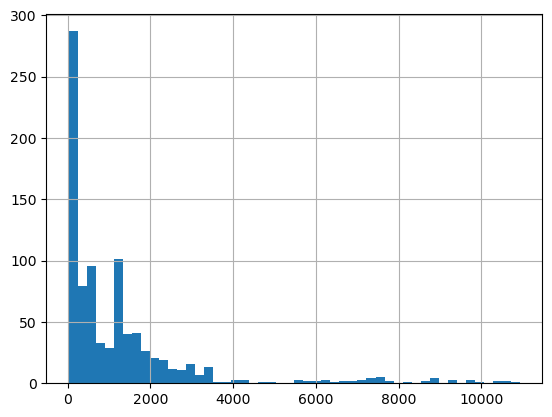

In [27]:
df['product_price'].hist(bins=50)

Top Companies by Count

<Axes: xlabel='company'>

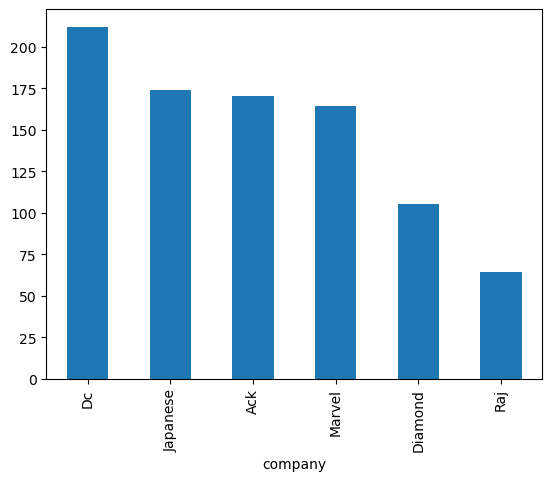

In [28]:
df["company"].value_counts().head(10).plot(kind="bar")

Average Rating by Publisher

<Axes: ylabel='company'>

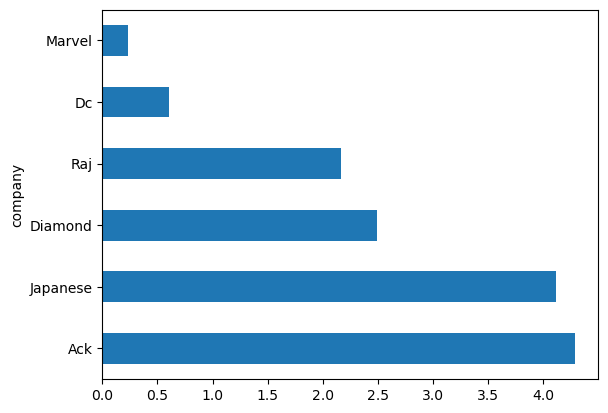

In [29]:
df.groupby("company")["product_rating"].mean().sort_values(ascending=False).head(10).plot(kind="barh")

Discount vs. Price Scatter

<Axes: xlabel='discount_pct', ylabel='product_price'>

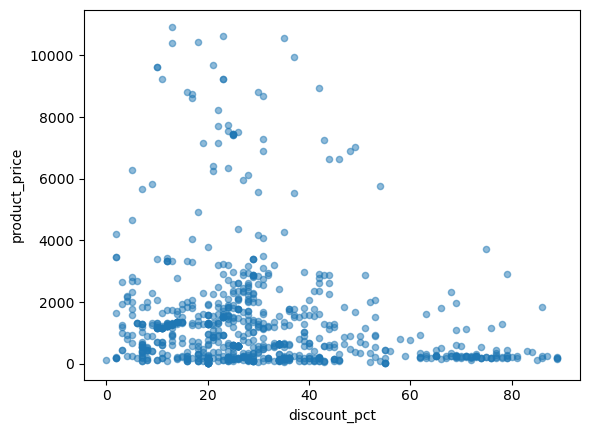

In [30]:
df.plot.scatter(x="discount_pct", y="product_price", alpha=0.5)

Language Distribution

<Axes: xlabel='language'>

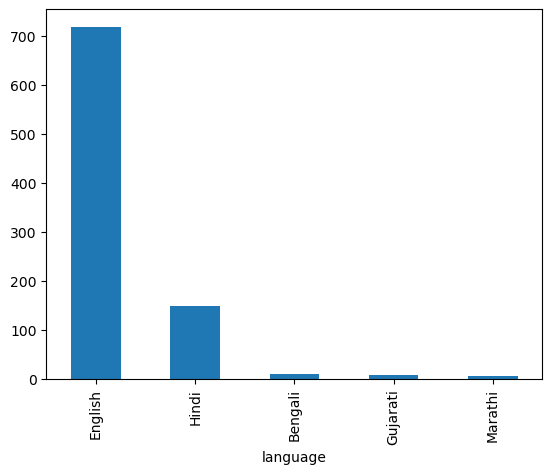

In [31]:
df["language"].value_counts().plot(kind="bar")

Format Popularity

<Axes: ylabel='count'>

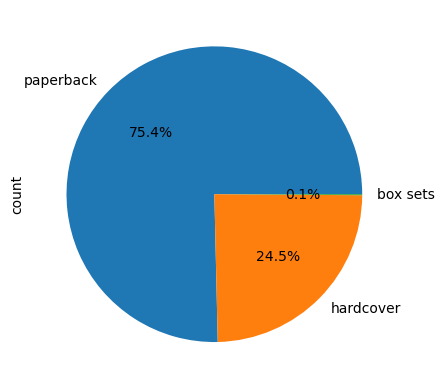

In [32]:
df["format"].value_counts().plot(kind="pie", autopct="%.1f%%")

Review Count by Company

<Axes: xlabel='company'>

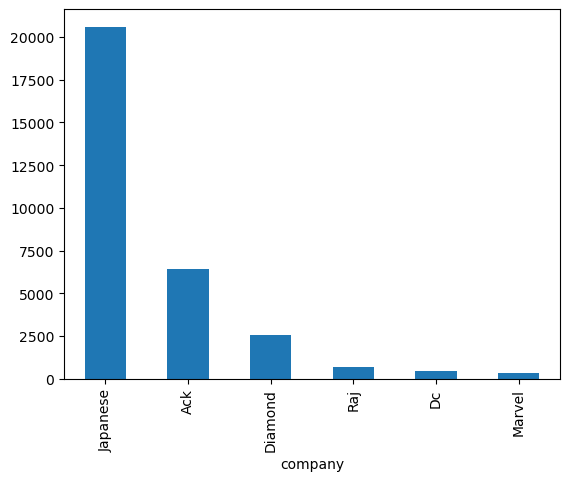

In [34]:
df.groupby("company")["review_count"].sum().sort_values(ascending=False).head(10).plot(kind="bar")

Countrywise Comic Count

<Axes: ylabel='country'>

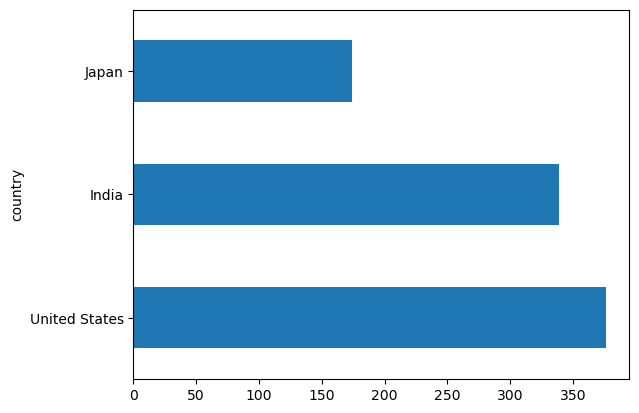

In [35]:
df["country"].value_counts().plot(kind="barh")

Top Writers by Comic Count

<Axes: ylabel='writer'>

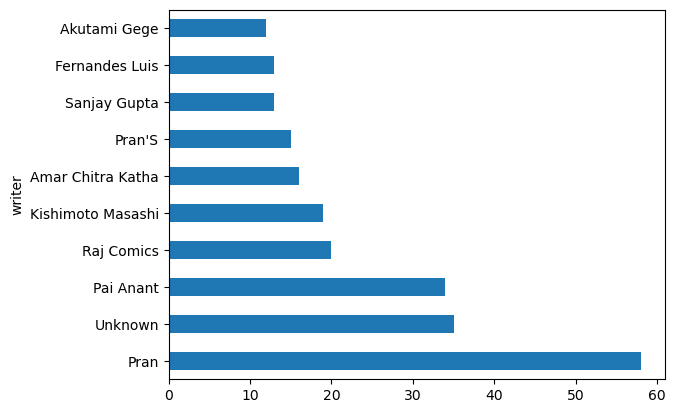

In [36]:
df["writer"].value_counts().head(10).plot(kind="barh")

Missing Values Heatmap

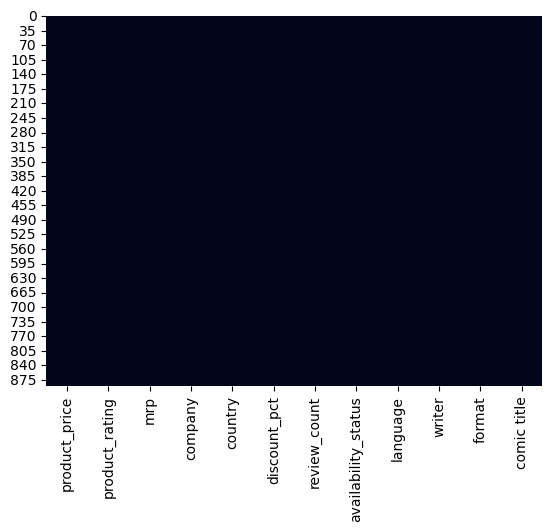

In [39]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

top publishers by average rating

In [44]:
avg_rating_by_publisher = df.groupby('company')['product_rating'].mean().sort_values(ascending=False)
print(avg_rating_by_publisher)

company
Ack         4.283529
Japanese    4.112069
Diamond     2.488571
Raj         2.167187
Dc          0.608019
Marvel      0.232927
Name: product_rating, dtype: float64


companies with the lowest average book prices:

In [45]:
avg_price_by_company = df.groupby('company')['product_price'].mean().sort_values()
lowest_price_publishers_df = avg_price_by_company.reset_index()
print(lowest_price_publishers_df)

    company  product_price
0   Diamond     331.428571
1       Ack     345.058824
2       Raj     635.125000
3  Japanese     736.275862
4        Dc    2321.702830
5    Marvel    2503.530488


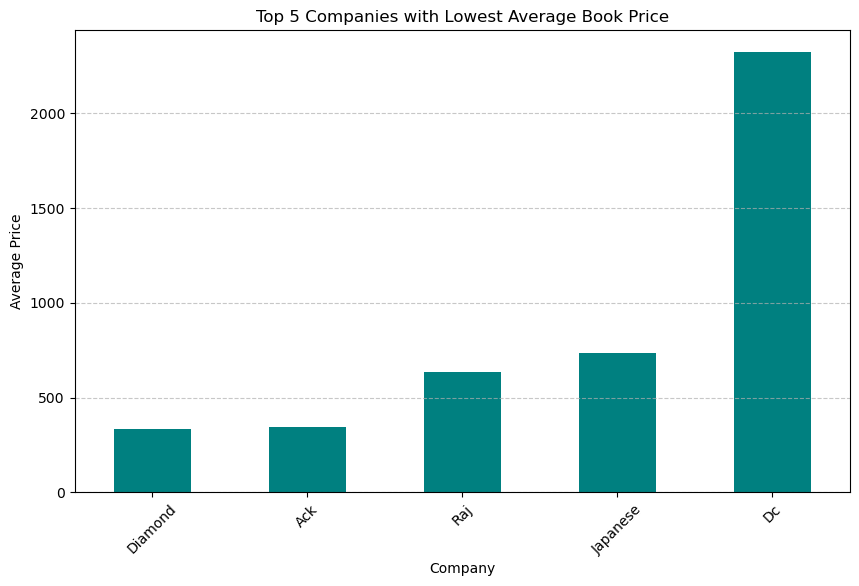

company
Diamond      331.428571
Ack          345.058824
Raj          635.125000
Japanese     736.275862
Dc          2321.702830
Marvel      2503.530488
Name: product_price, dtype: float64


In [48]:
avg_price_by_company = df.groupby('company')['product_price'].mean().sort_values()


plt.figure(figsize=(10,6))
avg_price_by_company.head(5).plot(kind='bar', color='teal')
plt.title('Top 5 Companies with Lowest Average Book Price')
plt.xlabel('Company')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print(avg_price_by_company)

factors contributing to lower comic book prices

In [49]:
# Filter dataset for low priced books (lower 25 percentile)
price_threshold = df['product_price'].quantile(0.25)
low_price_books = df[df['product_price'] <= price_threshold]

# Summary statistics for potential factors in low price segment
factors_summary = {
    'company_counts': low_price_books['company'].value_counts(),
    'language_counts': low_price_books['language'].value_counts(),
    'format_counts': low_price_books['format'].value_counts(),
    'availability_counts': low_price_books['availability_status'].value_counts(),
}

# Display the summaries
factors_summary

{'company_counts': company
 Ack         114
 Diamond      71
 Japanese     25
 Raj          13
 Marvel        3
 Name: count, dtype: int64,
 'language_counts': language
 English     148
 Hindi        61
 Bengali       8
 Gujarati      5
 Marathi       4
 Name: count, dtype: int64,
 'format_counts': format
 paperback    195
 hardcover     31
 Name: count, dtype: int64,
 'availability_counts': availability_status
 in_stock     89
 promotion    84
 low_stock    52
 other         1
 Name: count, dtype: int64}

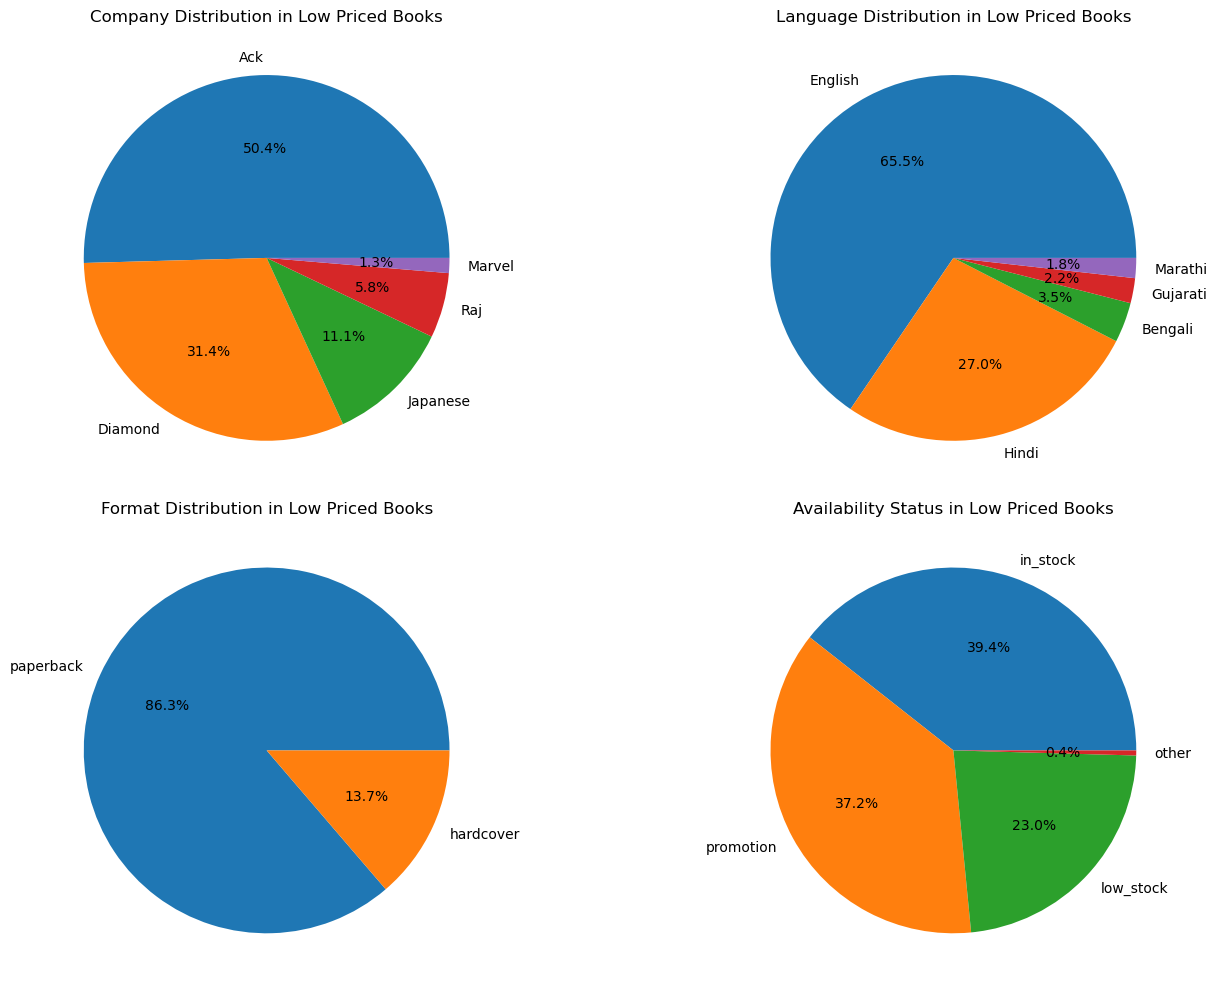

In [60]:

# Calculate factors summary for low-priced books
price_threshold = df['product_price'].quantile(0.25)
low_price_books = df[df['product_price'] <= price_threshold]

factors_summary = {
    'company_counts': low_price_books['company'].value_counts(),
    'language_counts': low_price_books['language'].value_counts(),
    'format_counts': low_price_books['format'].value_counts(),
    'availability_counts': low_price_books['availability_status'].value_counts(),
}

# Plot pie charts
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Company distribution pie chart
axes[0,0].pie(factors_summary['company_counts'], labels=factors_summary['company_counts'].index, autopct='%1.1f%%')
axes[0,0].set_title('Company Distribution in Low Priced Books')

# Language distribution pie chart
axes[0,1].pie(factors_summary['language_counts'], labels=factors_summary['language_counts'].index, autopct='%1.1f%%')
axes[0,1].set_title('Language Distribution in Low Priced Books')

# Format distribution pie chart
axes[1,0].pie(factors_summary['format_counts'], labels=factors_summary['format_counts'].index, autopct='%1.1f%%')
axes[1,0].set_title('Format Distribution in Low Priced Books')

# Availability status pie chart
axes[1,1].pie(factors_summary['availability_counts'], labels=factors_summary['availability_counts'].index, autopct='%1.1f%%')
axes[1,1].set_title('Availability Status in Low Priced Books')

plt.tight_layout()
plt.show()


In [50]:
highest_price_row = df.loc[df['product_price'].idxmax()]

# Extract relevant information
highest_price_book = {
    'comic_title': highest_price_row['comic title'],
    'company': highest_price_row['company'],
    'product_price': highest_price_row['product_price'],
    'product_rating': highest_price_row['product_rating'],
    'language': highest_price_row['language'],
    'format': highest_price_row['format']
}

print(highest_price_book)

{'comic_title': '100 Bullets Omnibus Volume 1', 'company': 'Dc', 'product_price': np.int64(10930), 'product_rating': np.float64(5.0), 'language': 'English', 'format': 'hardcover'}


In [51]:
high_price_threshold = df['product_price'].quantile(0.75)

# Filter high-priced comic books
high_price_books = df[df['product_price'] >= high_price_threshold]

# Analyze company and writer counts in high-priced comics
company_counts = high_price_books['company'].value_counts().head(10)
writer_counts = high_price_books['writer'].value_counts().head(10)

print('Top companies:\n', company_counts)
print('\nTop writers:\n', writer_counts)

Top companies:
 company
Dc          104
Marvel       89
Japanese     16
Ack           8
Raj           4
Diamond       3
Name: count, dtype: int64

Top writers:
 writer
Unknown             6
Waid Mark           6
Snyder Scott        6
Gaiman Neil         5
Various             5
Moench Doug         4
Claremont Chris     4
Morrison Grant      4
Buccellato Brian    4
Willingham Bill     4
Name: count, dtype: int64


How do ratings differ between high and low-priced comics

In [52]:
low_price_threshold = df['product_price'].quantile(0.25)
high_price_threshold = df['product_price'].quantile(0.75)

# Filter datasets
low_price_books = df[df['product_price'] <= low_price_threshold]
high_price_books = df[df['product_price'] >= high_price_threshold]

# Calculate average ratings
avg_rating_low = low_price_books['product_rating'].mean()
avg_rating_high = high_price_books['product_rating'].mean()

print(f'Average rating of low-priced comics: {avg_rating_low:.2f}')
print(f'Average rating of high-priced comics: {avg_rating_high:.2f}')

Average rating of low-priced comics: 3.65
Average rating of high-priced comics: 0.80


 top 10 comic books with the highest number of reviews, along with their rating and price company

In [54]:
# Sort by review count descending and pick top 10
top_reviews = df.sort_values(by='review_count', ascending=False).head(10)

# Select needed columns
result = top_reviews[['comic title', 'review_count', 'product_rating', 'product_price', 'company', 'discount_pct']]

result.reset_index(drop=True, inplace=True)
print(result)

                                         comic title  review_count  \
0                        Blue Lock, Volume 1 (Manga)           815   
1                    Uzumaki (3-in-1 Deluxe Edition)           815   
2                             Jujustu Kaisen Vol 3 (           698   
3      Attack On Titan Season 1 Part 1 Manga Box Set           698   
4                     Death Note, Vol. 10: Volume 10           606   
5                         Tsubasa: World Chronicle 1           606   
6                                         your name.           606   
7  COLOURED Dragon Ball Super Volume 15 + 1 free ...           606   
8                                  JUTUSU KAISEN 1-3           606   
9  That Time I Got Reincarnated as a Slime Season...           592   

   product_rating  product_price   company  discount_pct  
0             4.0            250  Japanese          86.0  
1             4.0            557  Japanese          74.0  
2             4.1            183  Japanese          

this shows the popularity of manga in indian market

 top 5 highest discount books country-wise along with their review counts:

In [59]:
df_sorted = df.sort_values(by='discount_pct', ascending=False)

# Group by country and pick top 5 books with highest discount
result = df_sorted.groupby('country').head(5)

# Select relevant columns
result_selected = result[['country', 'comic title', 'discount_pct', 'review_count', 'availability_status']]

result_selected.reset_index(drop=True, inplace=True)
print(result_selected)

          country                                        comic title  \
0           Japan  The Scum Villain's Self-Saving System: Ren Zha...   
1           Japan  The Scum Villain's Self-Saving System: Ren Zha...   
2           Japan  Grandmaster of Demonic Cultivation: Mo Dao Zu ...   
3           Japan                         Your Name., Vol. 1 (Manga)   
4           Japan  Heaven Official's Blessing: Tian Guan Ci Fu (N...   
5           India           MARD AUR MURDA SPECIAL COLLECTOR EDITION   
6   United States                                      Marvel Museum   
7           India  Chocoloony Designer CH25-DMSR02 Mauli Thread R...   
8   United States      Marvel's Captain Marvel: The Art of the Movie   
9           India                                   Indra and Shachi   
10          India                                           Ikigai -   
11          India                                   Krishnadeva Raya   
12  United States  The invincible Iron-Man first issue Comic wit

## Univariate analysis

Univariate Analysis on mrp column

count      889.000000
mean      1922.463442
std       2615.045163
min         40.000000
25%        300.000000
50%       1040.000000
75%       2100.000000
max      16416.000000
Name: mrp, dtype: float64


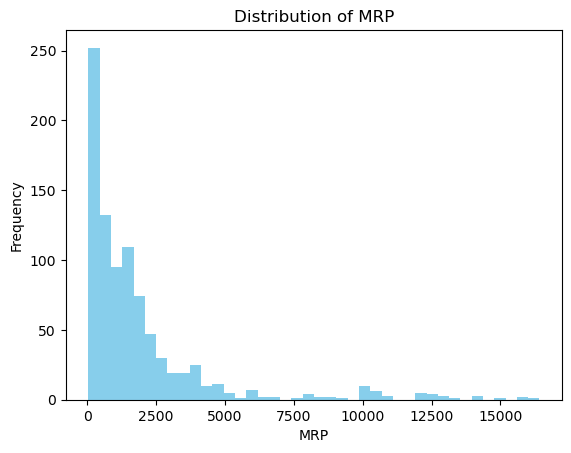

In [61]:
mrp_stats = df['mrp'].describe()
print(mrp_stats)

# Histogram for 'mrp' distribution
plt.hist(df['mrp'], bins=40, color='skyblue')
plt.title('Distribution of MRP')
plt.xlabel('MRP')
plt.ylabel('Frequency')
plt.show()

count      889.000000
mean      1310.461192
std       1831.365483
min         32.000000
25%        201.000000
50%        650.000000
75%       1558.000000
max      10930.000000
Name: product_price, dtype: float64


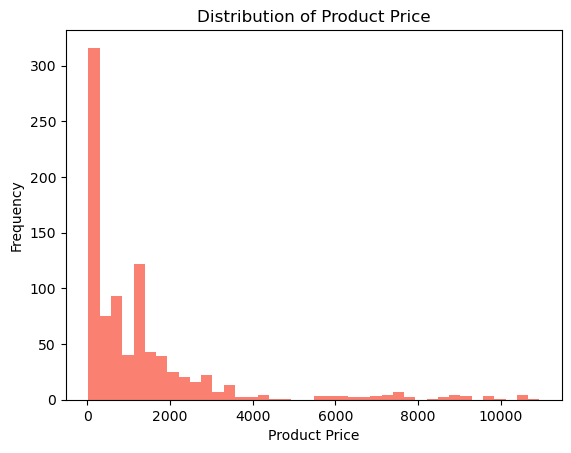

In [62]:
price_stats = df['product_price'].describe()
print(price_stats)

# Histogram for 'product_price' distribution
plt.hist(df['product_price'], bins=40, color='salmon')
plt.title('Distribution of Product Price')
plt.xlabel('Product Price')
plt.ylabel('Frequency')
plt.show()

 univariate analysis on the 'review_count' column

count    889.000000
mean      34.912261
std      104.576070
min        0.000000
25%        0.000000
50%        3.000000
75%       17.000000
max      815.000000
Name: review_count, dtype: float64


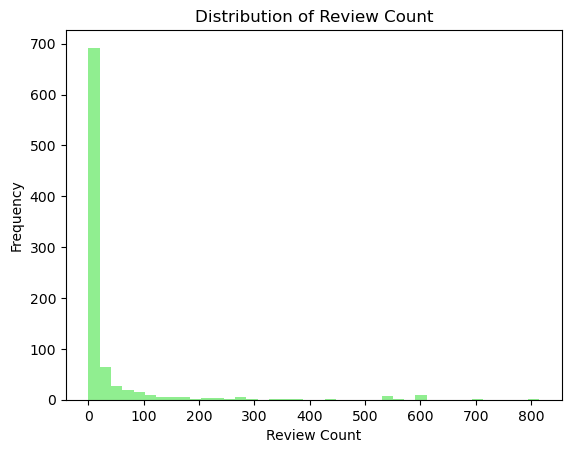

In [63]:
review_stats = df['review_count'].describe()
print(review_stats)

# Histogram for 'review_count' distribution
plt.hist(df['review_count'], bins=40, color='lightgreen')
plt.title('Distribution of Review Count')
plt.xlabel('Review Count')
plt.ylabel('Frequency')
plt.show()

lowest availability along with how many books each company has in the dataset

In [69]:
# Calculate availability counts for 'in_stock' status per company
in_stock_availability = pd.crosstab(df['company'], df['availability_status'])['in_stock']

# Count number of books per company
books_per_company = df['company'].value_counts()

# Combine into one DataFrame
df_summary = pd.DataFrame({'in_stock_availability': in_stock_availability, 'books_in_dataset': books_per_company})

# Sort companies by in_stock availability ascending
df_summary_sorted = df_summary.sort_values(by='in_stock_availability').reset_index().rename(columns={'index': 'company'})

print(df_summary_sorted.head(10))

    company  in_stock_availability  books_in_dataset
0       Raj                      9                64
1   Diamond                     28               105
2  Japanese                     56               174
3       Ack                     79               170
4    Marvel                    112               164
5        Dc                    149               212


countries dominating the comic book market based on the number of books

In [70]:
df_country_counts = df['country'].value_counts().reset_index()
df_country_counts.columns = ['country', 'book_count']

# Sort descending to find dominant countries
df_country_counts_sorted = df_country_counts.sort_values(by='book_count', ascending=False)
print(df_country_counts_sorted.head(10))

         country  book_count
0  United States         376
1          India         339
2          Japan         174


esult identifying writers who have the highest rated books (rating = 5.0), along with their associated countries and companies:

In [71]:
max_rating = df['product_rating'].max()
highest_rated_books = df[df['product_rating'] == max_rating]

# Extract unique writers, countries, and companies for these books
writers = highest_rated_books['writer'].unique()
countries = highest_rated_books['country'].unique()
companies = highest_rated_books['company'].unique()

print(f'Maximum Rating: {max_rating}')
print(f'Writers with highest rated books: {writers}')
print(f'Countries of highest rated books: {countries}')
print(f'Companies of highest rated books: {companies}')

Maximum Rating: 5.0
Writers with highest rated books: ['Aaron Jason' 'Azzarello Brian' 'Tamaki Mariko' 'Axelrod Jadzia'
 'Dido Dan' 'Morrison Grant' 'Wallace Daniel' 'Sanjay Gupta' 'Raj Gupta'
 'Raj Comics By Manoj Gupta' 'Raj Comics' 'Chandrakant Kamala' 'Editorial'
 'Karkaria Bachi' 'Chandrasekaran Gayathri' 'Unknown' 'Amar Chitra Katha'
 'Ugra Meera' 'Moonstone Rupa Publications India Amar Chitra Katha'
 'Pai Anant' 'Dutt Gayatri Madan' 'Seshadri Lakshmi' 'Sinha Urmila'
 'Fernandes Luis' 'Prans' 'Pran' "Pran'S" 'Mannu Prakash'
 'Togashi Yoshihiro' 'Kishimoto Masashi' 'Kusaka Hidenori'
 'Inoue Takehiko' 'Kentaro Miura']
Countries of highest rated books: ['United States' 'India' 'Japan']
Companies of highest rated books: ['Marvel' 'Dc' 'Raj' 'Ack' 'Diamond' 'Japanese']


with highest review

In [72]:
max_rating = df['product_rating'].max()
highest_rated_books = df[df['product_rating'] == max_rating]

# Among the highest rated, find the one(s) with the highest review count
max_review = highest_rated_books['review_count'].max()
highest_reviewed_books = highest_rated_books[highest_rated_books['review_count'] == max_review]

# Extract writers, countries, companies, max review count
writers = highest_reviewed_books['writer'].unique()
countries = highest_reviewed_books['country'].unique()
companies = highest_reviewed_books['company'].unique()

print(f'Maximum Rating: {max_rating}')
print(f'Highest Review Count Among Highest Rated: {max_review}')
print(f'Writer(s): {writers}')
print(f'Country(ies): {countries}')
print(f'Company(ies): {companies}')

Maximum Rating: 5.0
Highest Review Count Among Highest Rated: 22
Writer(s): ['Kishimoto Masashi']
Country(ies): ['Japan']
Company(ies): ['Japanese']


writers who have the most highly reviewed books by summing the review counts

In [73]:
# Group by writer and sum review counts to find writers with most highly reviewed books
writer_review_counts = df.groupby('writer')['review_count'].sum().sort_values(ascending=False)

# Top 10 writers by total review count
top_writers = writer_review_counts.head(10).reset_index()
top_writers.columns = ['writer', 'total_review_count']
print(top_writers)

                                     writer  total_review_count
0                              Akutami Gege                2111
1                                 Pai Anant                2101
2                         Masashi Kishimoto                1596
3                              Ohba Tsugumi                1460
4                                   Unknown                1335
5                              Gege Akutami                1209
6                                    Pran'S                1136
7  Muneyuki Kaneshiro Art By Yusuke Nomura.                 815
8                                 Ito Junji                 815
9                            Isayama Hajime                 767


In [1]:
# Bar chart
plt.figure(figsize=(12, 6))
top_writers.plot(kind='bar', color='skyblue')
plt.title('Top 10 Writers by Total Review Count')
plt.xlabel('Writer')
plt.ylabel('Total Review Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

relation between comic book format, average review count, and average product price

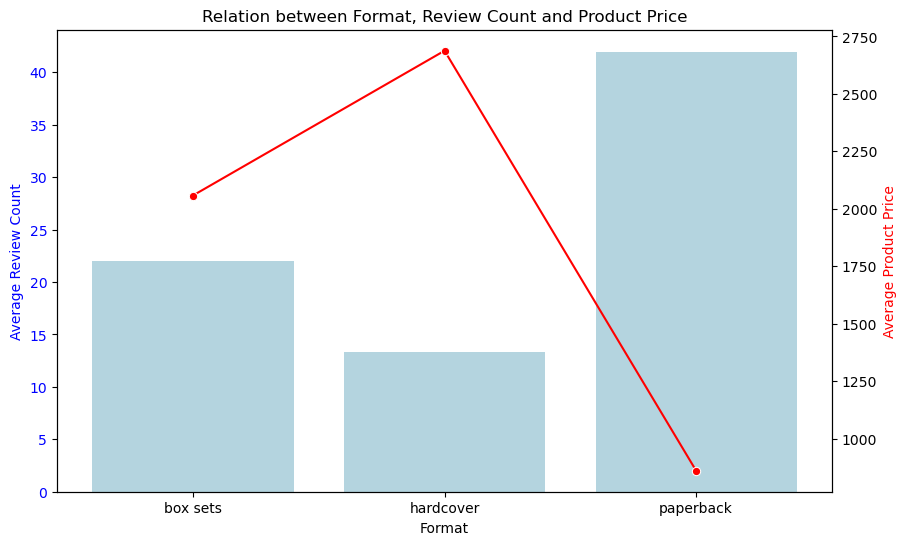

      format  review_count  product_price
0   box sets     22.000000    2058.000000
1  hardcover     13.302752    2687.692661
2  paperback     41.962687     861.231343


In [77]:
# Group data by format and calculate mean review count and mean product price
format_stats = df.groupby('format')[['review_count', 'product_price']].mean().reset_index()

# Plot review count and product price by format
fig, ax1 = plt.subplots(figsize=(10,6))

sns.barplot(x='format', y='review_count', data=format_stats, color='lightblue', ax=ax1)
ax1.set_ylabel('Average Review Count', color='blue')
ax1.set_xlabel('Format')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
sns.lineplot(x='format', y='product_price', data=format_stats, color='red', marker='o', ax=ax2)
ax2.set_ylabel('Average Product Price', color='red')

plt.title('Relation between Format, Review Count and Product Price')
plt.show()

print(format_stats)

 filter comics with "Chacha Chaudhary" or "Marvel" in the title and get the top 5 books by review count

In [78]:
# Filter comics containing 'Chacha Chaudhary' or 'Marvel' in the title
filtered_df = df[df['comic title'].str.contains('Chacha Chaudhary|Marvel', case=False, na=False)]

# Find top 5 comics by review count within filtered set
top_comics = filtered_df.sort_values(by='review_count', ascending=False).head(5)

# Display relevant columns
print(top_comics[['comic title', 'company', 'country', 'product_price', 'product_rating', 'review_count']])

                               comic title  company        country  \
617       Chacha Chaudhary Big Head Comics  Diamond          India   
630              Chacha Chaudhary Digest-1  Diamond          India   
633             Chacha Chaudhary Digest -2  Diamond          India   
640              Chacha Chaudhary Digest 3  Diamond          India   
7    Marvel Black Panther Wakanda Forever!   Marvel  United States   

     product_price  product_rating  review_count  
617            100             4.2           374  
630            148             4.4           286  
633            160             4.4           231  
640            160             4.4           156  
7              299             4.7           138  


the company that provides the highest rated book with the lowest price

In [79]:
# Find the highest rating
max_rating = df['product_rating'].max()

# Filter rows with max rating
highest_rated = df[df['product_rating'] == max_rating]

# Find the row with the lowest price among highest rated
lowest_price_row = highest_rated.loc[highest_rated['product_price'].idxmin()]

# Extract company, title, rating and price
result = {
    'company': lowest_price_row['company'],
    'comic_title': lowest_price_row['comic title'],
    'product_rating': lowest_price_row['product_rating'],
    'product_price': lowest_price_row['product_price']
}

print(result)

{'company': 'Ack', 'comic_title': 'Birbal to the Rescue', 'product_rating': np.float64(5.0), 'product_price': np.int64(40)}


Price Distribution by Format: Further analyze how pricing varies between paperback, hardcover, and box sets

C:\Users\Sanket Jadhav\AppData\Local\Temp\ipykernel_19444\3958184287.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_trim, x='format', y='product_price', palette='Set2')


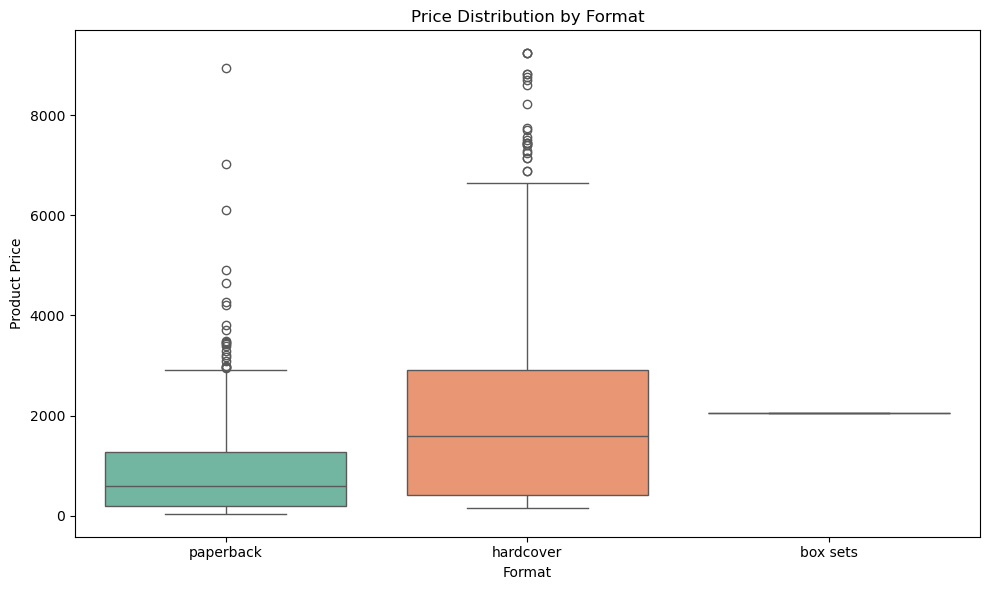

           count         mean          std     min     25%     50%     75%  \
format                                                                       
box sets     1.0  2058.000000          NaN  2058.0  2058.0  2058.0  2058.0   
hardcover  218.0  2687.692661  2848.604809   155.0   458.5  1716.0  3320.0   
paperback  670.0   861.231343   999.357539    32.0   188.0   591.0  1277.0   

               max  
format              
box sets    2058.0  
hardcover  10930.0  
paperback   9939.0  


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Comicbook.csv')

# Prepare data: Remove outliers for clearer visualization (optional)
q_low = df['product_price'].quantile(0.01)
q_high = df['product_price'].quantile(0.99)
df_trim = df[(df['product_price'] >= q_low) & (df['product_price'] <= q_high)]

# Price distribution by format using boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df_trim, x='format', y='product_price', palette='Set2')
plt.title('Price Distribution by Format')
plt.xlabel('Format')
plt.ylabel('Product Price')
plt.tight_layout()
plt.show()

# Summary statistics for price by format
format_price_stats = df.groupby('format')['product_price'].describe()
print(format_price_stats)


Descriptive Statistics Per Country
Number of comics per country (market size).

Average, median, and distribution of prices, ratings, and review counts.

In [13]:
from pprint import pprint


countries = df['country'].unique()

# Prepare descriptive statistics per country
summary = {}
for country in countries:
    data = df[df['country'] == country]
    summary[country] = {
        'comic_count': len(data),
        'price_mean': data['product_price'].mean(),
        'price_median': data['product_price'].median(),
        'price_min': data['product_price'].min(),
        'price_max': data['product_price'].max(),
        'rating_mean': data['product_rating'].mean(),
        'rating_median': data['product_rating'].median(),
        'rating_min': data['product_rating'].min(),
        'rating_max': data['product_rating'].max(),
        'reviews_mean': data['review_count'].mean(),
        'reviews_median': data['review_count'].median(),
        'reviews_min': data['review_count'].min(),
        'reviews_max': data['review_count'].max(),
    }
pprint(summary)

{'India': {'comic_count': 339,
           'price_max': 6108,
           'price_mean': np.float64(395.59882005899703),
           'price_median': 190.0,
           'price_min': 32,
           'rating_max': 5.0,
           'rating_mean': np.float64(3.3280235988200593),
           'rating_median': 4.4,
           'rating_min': 0.0,
           'reviews_max': 438,
           'reviews_mean': np.float64(28.492625368731563),
           'reviews_median': 7.0,
           'reviews_min': 0},
 'Japan': {'comic_count': 174,
           'price_max': 9939,
           'price_mean': np.float64(736.2758620689655),
           'price_median': 417.5,
           'price_min': 112,
           'rating_max': 5.0,
           'rating_mean': np.float64(4.112068965517241),
           'rating_median': 4.3,
           'rating_min': 0.0,
           'reviews_max': 815,
           'reviews_mean': np.float64(118.39080459770115),
           'reviews_median': 23.0,
           'reviews_min': 0},
 'United States': {'comic_coun

most prominent comic book companies, most reviewed writers, and highest rated writers by country

In [15]:
countries = df['country'].unique()

result = {}

for country in countries:
    data = df[df['country'] == country]
    # Top 5 companies by number of books
    top_companies = data['company'].value_counts().head(5).to_dict()

    # Top 5 most reviewed writers by total review count
    top_reviewed_writers = data.groupby('writer')['review_count'].sum().sort_values(ascending=False).head(5).to_dict()

    # Top 5 highest rated writers by average rating (with more than 1 book)
    writer_counts = data['writer'].value_counts()
    writer_avg_rating = data.groupby('writer')['product_rating'].mean()
    qualified_writers = writer_counts[writer_counts > 1].index
    top_rated_writers = writer_avg_rating.loc[qualified_writers].sort_values(ascending=False).head(5).to_dict()

    result[country] = {
        'top_companies': top_companies,
        'top_reviewed_writers': top_reviewed_writers,
        'top_rated_writers': top_rated_writers
    }

pprint(result)

{'India': {'top_companies': {'Ack': 170, 'Diamond': 105, 'Raj': 64},
           'top_rated_writers': {'Amar Chitra Katha Private Limited': 4.625,
                                 'Chandrasekaran Gayathri': 5.0,
                                 'Dutt Gayatri Madan': 5.0,
                                 'Fernandes Luis': 4.561538461538461,
                                 'Tarun Kumar Wahi': 4.633333333333334},
           'top_reviewed_writers': {'Amar Chitra Katha': 572,
                                    'Fernandes Luis': 605,
                                    'Pai Anant': 2101,
                                    "Pran'S": 1136,
                                    'Unknown': 1118}},
 'Japan': {'top_companies': {'Japanese': 174},
           'top_rated_writers': {'Gotouge Koyoharu': 4.475,
                                 'Inoue Takehiko': 4.8,
                                 'Kaneshiro Muneyuki': 4.366666666666666,
                                 'Ohba Tsugumi': 4.3875,
         

 format preference and price comparison by format within each country

In [16]:
# Distribution of book formats by country
format_distribution = df.groupby(['country', 'format']).size().unstack(fill_value=0)

# Price comparison by format within each country (mean price)
price_comparison = df.groupby(['country', 'format'])['product_price'].mean().unstack()

print(format_distribution)
print(price_comparison)

format         box sets  hardcover  paperback
country                                      
India                 1         66        272
Japan                 0          5        169
United States         0        147        229
format         box sets    hardcover    paperback
country                                          
India            2058.0   474.075758   370.444853
Japan               NaN  1407.800000   716.408284
United States       NaN  3725.095238  1551.052402


language analysis showing dominant comic book languages by country and their correlation with ratings and review counts

In [17]:
# Dominant comic book languages by country
language_distribution = df.groupby(['country', 'language']).size().unstack(fill_value=0)

# Average ratings and review counts by language
language_stats = df.groupby('language')[['product_rating', 'review_count']].mean()

print(language_distribution)
print(language_stats)

language       Bengali  English  Gujarati  Hindi  Marathi
country                                                  
India               10      170         7    147        5
Japan                0      174         0      0        0
United States        0      375         0      1        0
          product_rating  review_count
language                              
Bengali         3.870000     15.000000
English         2.173713     39.133519
Gujarati        1.900000      2.142857
Hindi           2.581757     18.054054
Marathi         2.760000     12.600000


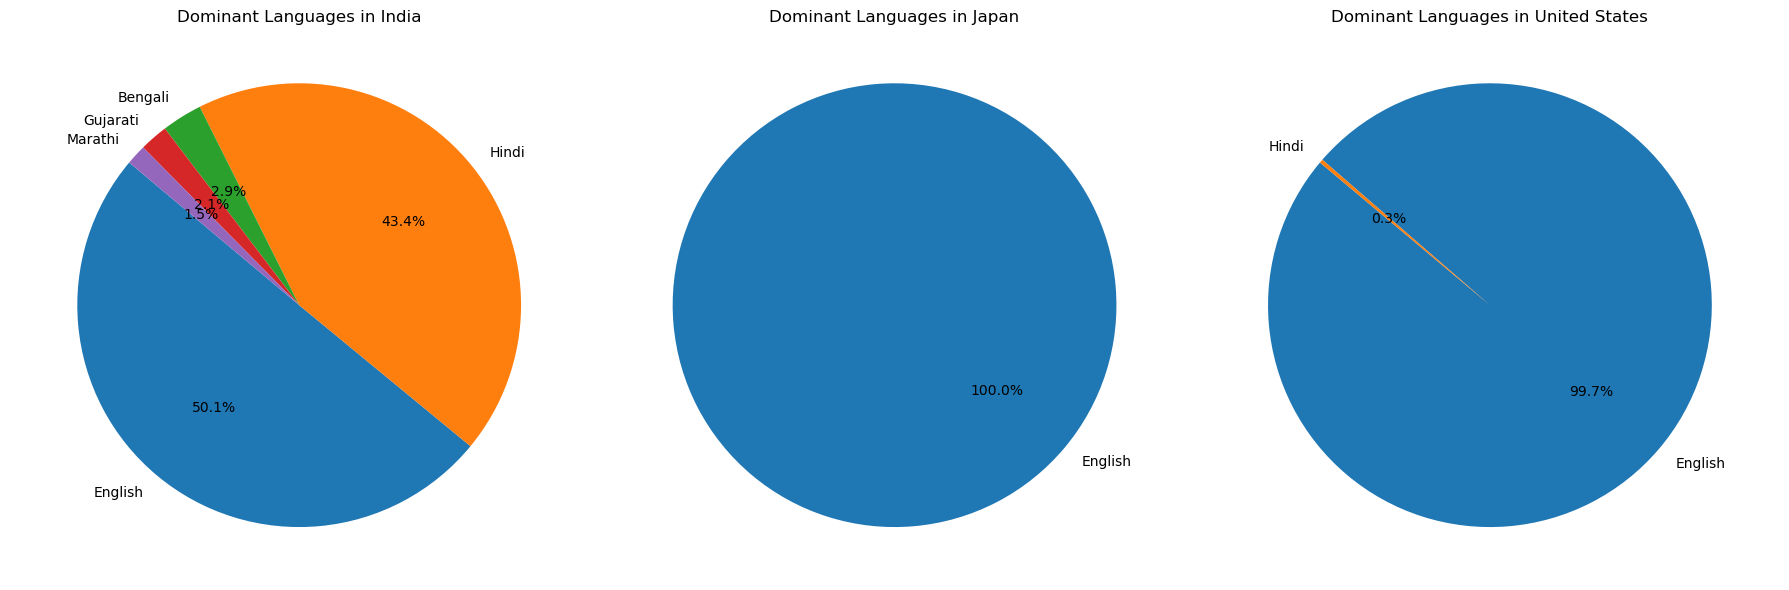

In [21]:
countries = ['India', 'Japan', 'United States']

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for i, country in enumerate(countries):
    language_distribution = df[df['country'] == country]['language'].value_counts()

    axs[i].pie(language_distribution, labels=language_distribution.index, autopct='%1.1f%%', startangle=140)
    axs[i].set_title(f'Dominant Languages in {country}')
    axs[i].axis('equal')  # Equal aspect ratio ensures pie is circular

plt.tight_layout()
plt.show()

Highest reviewed and top-rated comics by country.
Most discounted and best-selling books 

In [18]:
result = {}

for country in df['country'].unique():
    data = df[df['country'] == country]

    # Highest reviewed comics (top 5)
    top_reviewed = data.sort_values(by='review_count', ascending=False).head(5)[
        ['comic title', 'company', 'review_count', 'product_rating']]

    # Highest rated comics (top 5)
    top_rated = data.sort_values(by='product_rating', ascending=False).head(5)[
        ['comic title', 'company', 'product_rating', 'review_count']]

    # Most discounted books (top 5) if MRP exists
    if 'mrp' in df.columns:
        data['discount_percent'] = ((data['mrp'] - data['product_price']) / data['mrp']) * 100
        top_discounted = data.sort_values(by='discount_percent', ascending=False).head(5)[
            ['comic title', 'company', 'mrp', 'product_price', 'discount_percent']]
    else:
        top_discounted = pd.DataFrame()

    result[country] = {
        'top_reviewed': top_reviewed,
        'top_rated': top_rated,
        'top_discounted': top_discounted
    }

print(result)


{'United States': {'top_reviewed':                                      comic title company  review_count  \
347              Manjaveyil MaranangalMalayalam,      Dc           222   
7          Marvel Black Panther Wakanda Forever!  Marvel           138   
5        Avengers Epic Collection: Taking A.I.M.  Marvel           138   
199             Aquaman Volume 1: Unspoken Water      Dc            40   
244  The Joker: Death of the Family (The New 52)      Dc            26   

     product_rating  
347             4.7  
7               4.7  
5               4.7  
199             4.7  
244             4.9  , 'top_rated':                                         comic title company  product_rating  \
178                    100 Bullets Omnibus Volume 1      Dc             5.0   
357                       DC Comics: Super-Villains      Dc             5.0   
4                    Avengers By Jason Aaron Vol. 9  Marvel             5.0   
185  Batman: Detective Comics Vol. 3: Arkham Rising      D

C:\Users\Sanket Jadhav\AppData\Local\Temp\ipykernel_19444\3743590652.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['discount_percent'] = ((data['mrp'] - data['product_price']) / data['mrp']) * 100
C:\Users\Sanket Jadhav\AppData\Local\Temp\ipykernel_19444\3743590652.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['discount_percent'] = ((data['mrp'] - data['product_price']) / data['mrp']) * 100
C:\Users\Sanket Jadhav\AppData\Local\Temp\ipykernel_19444\3743590652.py:16: SettingWithCopyWar

stock status comparison between countries with a stacked bar chart

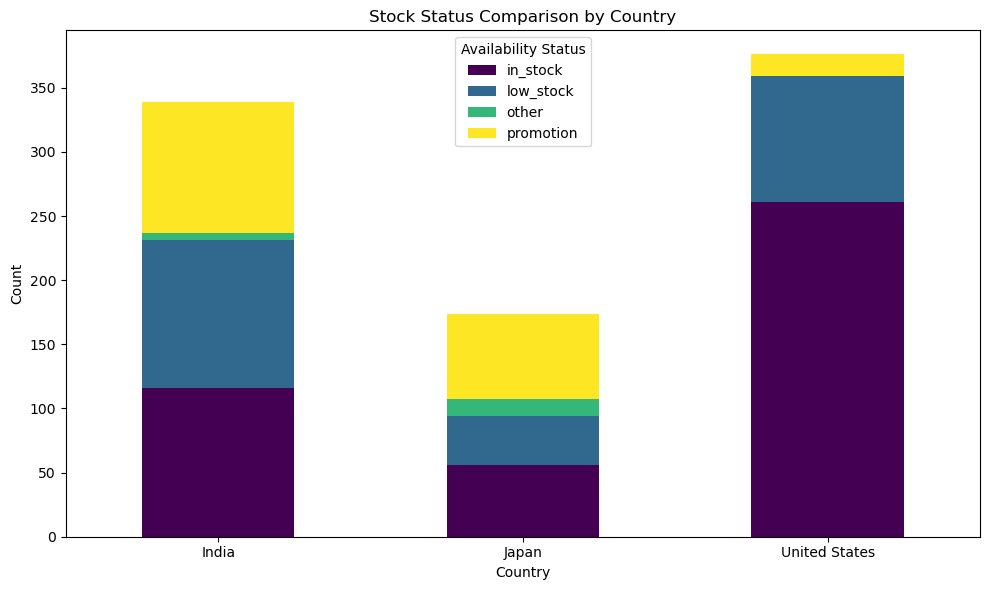

In [19]:
df_availability = pd.crosstab(df['country'], df['availability_status'])

# Plot stacked bar chart comparing stock status by country
df_availability.plot(kind='bar', figsize=(10,6), stacked=True, colormap='viridis')
plt.title('Stock Status Comparison by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Availability Status')
plt.tight_layout()
plt.show()


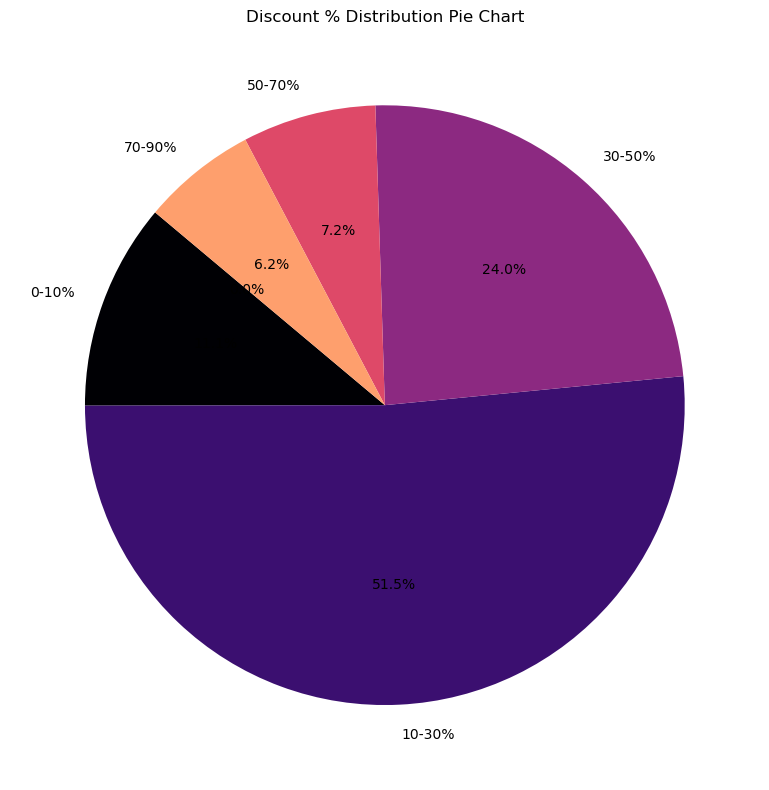

In [18]:

# Categorize discount_pct into bins
bins = [0, 10, 30, 50, 70, 90, 100]
labels = ['0-10%', '10-30%', '30-50%', '50-70%', '70-90%', '90-100%']
df['discount_bin'] = pd.cut(df['discount_pct'], bins=bins, labels=labels, include_lowest=True)

# Count number of products in each discount bin
discount_dist = df['discount_bin'].value_counts().sort_index()


# Plot pie chart with labels
plt.figure(figsize=(8,8))
discount_dist.plot(kind='pie', labels=discount_dist.index, autopct='%1.1f%%', startangle=140, cmap='magma')
plt.ylabel('')
plt.title('Discount % Distribution Pie Chart')
plt.tight_layout()
plt.show()

## Final Conclusion
Japan offers the best quality and engagement.
India provides the most affordable options.
Paperback format gives the best value for students.
